In [1008]:
from typing import Dict, Literal
import colour
import numpy as np
#from colour import sd_gaussian, sd_zeros, sd_constant, SpectralDistribution, MSDS_CMFS, SDS_ILLUMINANTS
from colormath.color_objects import sRGBColor

COLORED_SPECIES = { # (wavelength, FWHM, epsilon)
    'CrO4-2': (370, 60, 5000),
    'HCrO4-': (350, 60, 2000),
    'Cr2O7-2': [(350, 70, 3000), (440, 110, 400)],
    'Cu+2': (800, 230, 20),
    'Cu(NH3)4+2': (600, 170, 20),
    'Ni+2': [(400, 100, 12), (610, 80, 6), (690, 80, 7)],
    'Ni(NH3)6+2': [(375, 65, 20), (575, 60, 15)],
    'Co+2': [(466, 45, 6), (512, 62, 10), (600, 150, 0.7)],
    'Co(NH3)6+2': [(450, 50, 6), (500, 65, 9), (650, 150, 3), (550, 1000, 1.5)],
    'Fe2OH2+4': (340, 70, 3500),
    'FeCl+2': (335, 80, 1000), # DOI: 10.1016/j.chemgeo.2006.02.005
    'FeCl2+': (345, 80, 3800), # DOI: 10.1016/j.chemgeo.2006.02.005
    'FeCl3': (375, 90, 3000), # DOI: 10.1016/j.chemgeo.2006.02.005
    'FeSCN+2': (460, 85 , 5000),
    'Fe(SCN)2+': (485, 85, 9000),
    'Fe(Ox)':    (340, 100, 70),    # DOI: 10.1021/jp8040583
    'Fe(Ox)2-2': (350, 120, 130),   # DOI: 10.1021/jp8040583
    'FeOx+':     (300, 100, 1000),  # DOI: 10.1021/jp8040583
    'Fe(Ox)2-':  (300, 100, 2000),  # DOI: 10.1021/jp8040583
    'Fe(Ox)3-3': (300, 100, 3000),  # DOI: 10.1021/jp8040583
    
}

SPECTRA = {}
for sp, peaks in COLORED_SPECIES.items():
    spectrum = colour.sd_zeros()
    if type(peaks) == tuple:
        peaks = [peaks]
    for peak in peaks:
        wavelength = peak[0]
        fwhm = peak[1]
        epsilon = peak[2]
        spectrum += colour.sd_gaussian(wavelength, fwhm, method='FWHM') * epsilon
    SPECTRA[sp] = spectrum

def absorption_spectrum(composition: Dict[str, float]) -> colour.SpectralDistribution:
    
    sol_spec = colour.sd_zeros(name='absorbance spectrum')
    for sp, spectrum in SPECTRA.items():
        conc = composition.get(sp, 0)
        sol_spec += spectrum * conc
    
    return sol_spec

CMFS = colour.MSDS_CMFS['CIE 1931 2 Degree Standard Observer']     
ILLUM = colour.SDS_ILLUMINANTS['D65'].copy().align(CMFS.shape) 

def solution_color(composition: Dict[str, float], optical_path_length: float=2, out: Literal['rgb', 'hex']='hex') -> str:
    
    abs_spec = absorption_spectrum(composition)
    abs = abs_spec * optical_path_length
    transmittance = (colour.sd_constant(0.1) ** (abs)).align(CMFS.shape)
    transmittance.normalise()

    xyz = colour.sd_to_XYZ(transmittance, CMFS, ILLUM)
    rgb = colour.XYZ_to_sRGB(xyz/100)
    rgb = np.clip(rgb, 0, 1)
    if out.lower() == 'rgb':
        return rgb
    elif out.lower() == 'hex':
        hex = sRGBColor(*rgb).get_rgb_hex()
        return hex
    else:
        raise ValueError(f"Invalid output type: {out!r}. Must be either 'rgb' or 'hex'. ")

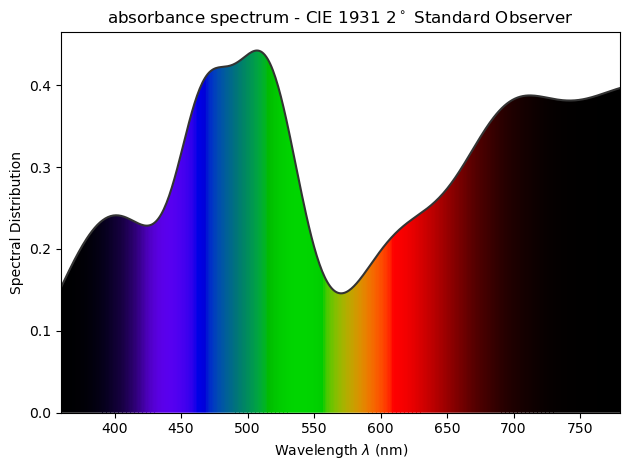

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'absorbance spectrum - CIE 1931 2$^\\circ$ Standard Observer'}, xlabel='Wavelength $\\lambda$ (nm)', ylabel='Spectral Distribution'>)

In [1017]:
from colour.plotting import plot_single_sd

comp = {'Cu+2': 0.02, 'Ni+2': 0.02, 'Co+2': 0.04}
spec = absorption_spectrum(comp)
plot_single_sd(spec)

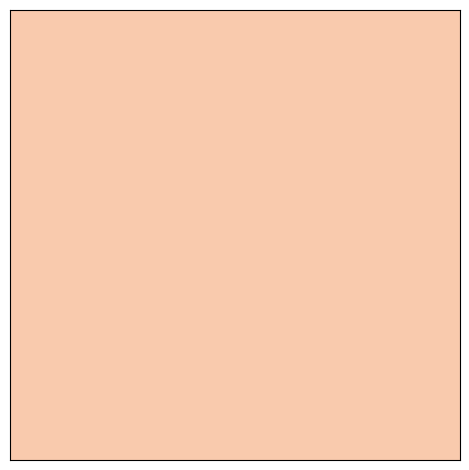

(<Figure size 640x480 with 1 Axes>, <Axes: >)

In [1018]:
from colour.plotting import plot_single_colour_swatch

rgb = solution_color(comp, out='rgb')
hex = solution_color(comp, out='hex')

plot_single_colour_swatch(rgb)

In [1]:
from engine import Solution, set_chemical_system

In [13]:
sys = set_chemical_system('Cu Co Ni N Cr Fe Cl')

In [59]:
sol = Solution({'Ni+2': 0.01, 'Fe+3': 0.05, 'H+': 0.13, 'Cl-': 0.3 }, volume=50)

In [60]:
sol.equilibrate()

In [61]:
sol.has_precipitate

False

In [62]:
sol.composition

{'H+': 0.13016112517437972,
 'OH-': 7.624930046454655e-14,
 'Cl-': 0.22910608061448084,
 'Ni+2': 0.009999999990400753,
 'Fe+3': 0.0032871526451905904,
 'NiOH+': 9.599246053296903e-12,
 'FeOH+2': 0.0001581455573509987,
 'Fe2OH2+4': 1.1171596799688452e-06,
 'Fe(OH)2+': 3.726439892692167e-07,
 'FeCl+2': 0.022743523520520944,
 'FeCl2+': 0.0232753180757666,
 'FeCl3': 0.0005332532378216683}

In [64]:
sol.color_name

'pale yellowish green'

In [ ]:
import numpy as np

l_bins = np.array([0.2, 0.3, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9])
l_prefix = {
    1: 'dark',
    2: 'deep',
    3: 'bright',
    4: '',
    5: 'light',
    6: 'pale',
    7: 'very pale'
}

l = 0.89
lightness_prefix[np.digitize(l, lightness_bins)]

'very pale'

In [1019]:
hex

'#f9caad'

In [989]:
from colors import closest_color_names

closest_color_names(hex)

{'wheat'}

In [536]:
xyz

NameError: name 'xyz' is not defined

In [579]:
rgb

array([ 0.80039434,  0.86592638, -0.92812178])

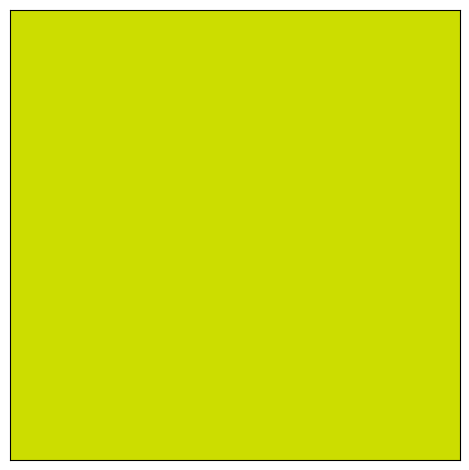

(<Figure size 640x480 with 1 Axes>, <Axes: >)

In [580]:
plot_single_colour_swatch(rgb)

In [349]:
sd = SpectralDistribution(data=spec)
ill = SDS_ILLUMINANTS['D65']
cmfs = MSDS_CMFS['CIE 1931 2 Degree Standard Observer']

NameError: name 'SpectralDistribution' is not defined

In [231]:
sd = sd.copy().align(cmfs.shape)
ill = ill.copy().align(cmfs.shape)

In [232]:
xyz = sd_to_XYZ(ill * sd, cmfs=cmfs, ill=ill)
xyz = xyz / np.max(xyz)
srgb = XYZ_to_sRGB(xyz)
srgb = np.clip(srgb, 0, 1)
hex = sRGBColor(*srgb).get_rgb_hex()

In [3]:
from colour.notation import CSS_COLOR_3_BASIC

In [8]:
CSS_COLOR_3_BASIC

CanonicalMapping({'black': '#000000', 'silver': '#C0C0C0', 'gray': '#808080', 'white': '#FFFFFF', 'maroon': '#800000', 'red': '#FF0000', 'purple': '#800080', 'fuchsia': '#FF00FF', 'green': '#008000', 'lime': '#00FF00', 'olive': '#808000', 'yellow': '#FFFF00', 'navy': '#000080', 'blue': '#0000FF', 'teal': '#008080', 'aqua': '#00FFFF'})

In [220]:
hex = srgb.get_rgb_hex()

AttributeError: 'numpy.ndarray' object has no attribute 'get_rgb_hex'

In [103]:
xyz

array([ 0.52597199,  0.45521818,  0.01880984])

In [67]:
from engine import StockSolution, Solution, set_chemical_system

In [144]:
sys = set_chemical_system('N(-3) Cl')

In [145]:
nh3= StockSolution({'NH3': 1})
nh4cl = StockSolution({'NH4+': 1, 'Cl-': 1})

In [146]:
test1 = 10*nh3 + 10*nh4cl

In [147]:
test1.equilibrate()

In [148]:
test1.pH

9.249970070222384

In [149]:
test2 = 9*nh3 + 11*nh4cl
test2.equilibrate()
test2.pH

9.162825110107494

In [ ]:
test3 = 8*nh3 + 12*nh4cl
test3.equilibrate()
test3.pH

9.073887990335969

In [151]:
test4= 7.5*nh3 + 12.5*nh4cl
test4.equilibrate()
test4.pH

9.0281321335318

In [152]:
test5 = 7*nh3 + 13*nh4cl
test5.equilibrate()
test5.pH

8.981137019182151

In [163]:
sol = Solution({'NH3': 0.36, 'NH4+': 0.64, 'Cl-': 1}, volume=50)
sol.equilibrate()
sol.pH

9.000104417171084

In [ ]:
        - Reagents are not shown by tool. Use the `get_available_reagents` tool to check the available reagents.
        - This tool does not report the color if items, use the `checkout_color` tool to observe the color of a specifi item.
        - The observations made during an experiment involving an item are not stored in the Inventory.

In [6]:
'\n'.join([str({
    "label": "sample", 
    "type": "clear solution",
    "description": "unknown",
    "remaining_volume": "11 mL",
 }),
 str({
    "label": "test_1", 
    "type": "clear solution",
    "description": "9 mL sample + 1 mL HCl(1M)",
    "remaining_volume": "0 mL",
 }),
 str({
     "label": "test_2_filtrate",
     "type": "clear solution",
     "description": "5 mL test_1 + 1 mL NH4I --> filtered",
     "remaining_volume": "6 mL"
 }),
str({
    "label": "test_2_precipitate",
    "type": "precipitate",
    "description": "5 mL test_1 + 1 mL NH4I --> precipitate collected"
})])

"{'label': 'sample', 'type': 'clear solution', 'description': 'unknown', 'remaining_volume': '11 mL'}\n{'label': 'test_1', 'type': 'clear solution', 'description': '9 mL sample + 1 mL HCl(1M)', 'remaining_volume': '0 mL'}\n{'label': 'test_2_filtrate', 'type': 'clear solution', 'description': '5 mL test_1 + 1 mL NH4I --> filtered', 'remaining_volume': '6 mL'}\n{'label': 'test_2_precipitate', 'type': 'precipitate', 'description': '5 mL test_1 + 1 mL NH4I --> precipitate collected'}"

In [4]:
hex = mix_colors([("EEEEEE", 0.2), ("00E0E0", 0.2), ("EF83EF", 0.6)])
closest_color_names(hex, mode='precipitate', max_names=1)

'lavender'

In [140]:
test2.has_precipitate

True

In [141]:
test2.precipitate.color_name

'white'

In [142]:
test2.precipitate

Precipitate(composition={'Fe(OH)3': 3.3104662507703614e-07, 'Al(OH)3': 0.00032351108390081177}, description=None)

In [143]:
test2.composition

{'H+': 6.855479827588234e-14,
 'OH-': 0.14388178059924878,
 'K+': 0.7692307692307693,
 'NO3-': 0.6153846153846345,
 'Al(OH)2+': 9.289489611667353e-17,
 'Al(OH)4-': 0.009954187196952251,
 'Fe(OH)2+': 3.872503807885169e-16,
 'Fe(OH)4-': 1.018605000249195e-05}